# UTCI NN Hyperparameter Search

The aim of this script is to select justified hyperparameters for the UTCi NN model. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, max_error, mean_absolute_error
import os

#### Set seed for reproducability

In [3]:
torch.manual_seed(6042)
np.random.seed(6042)

### Load the training and testing data
Download the following into the data folder

Training data: 
https://link.springer.com/article/10.1007/s00484-011-0454-1#SecESM1 -> Electronic supplementary material 4

Testing data:
https://zenodo.org/records/5503968

In [4]:
esm4 = pd.read_csv('../data/ESM_4_Table_Offset.DAT', sep='\t', comment='*')
test = pd.read_csv('../data/UTCI-Test-Data.txt', sep='\t', comment='#')

### Prepare data for training

In [5]:
# Make a collumn with the UTCI calculated by the Faila Model
esm4['UTCI'] = esm4['Offset'] + esm4['Ta']
esm4['Tr'] = esm4['Tr-Ta'] + esm4['Ta']

# Prepare test set
test['Offset'] = test['UTCI'] - test['Ta']
test['Tr'] = test['Tr-Ta'] + test['Ta']

# Test, validation split
features = ['Ta','Tr','va','pa']
X = esm4.loc[:, features]
y = esm4.loc[:, ['Offset']]
X_train, X_val, y_train, y_val= train_test_split(X, y, random_state=0, train_size = .90) # 90% training and 10% test, expert judgement Dr. Tianning Tang

X_test, y_test = test.loc[:, features], test.loc[:, ['Offset']]

In [10]:
# Standard metrics
y_true = test['UTCI'].values
y_pred = test['UTCI_polynomial'].values
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mbe = np.mean(y_pred - y_true)  # Mean Bias Error
r2 = r2_score(y_true, y_pred)
print(f'Polynomial Model - MAE: {mae:.4f}, RMSE: {rmse:.4f}, MBE: {mbe:.4f}, R2: {r2:.4f}')

Polynomial Model - MAE: 1.3329, RMSE: 2.7765, MBE: 0.3485, R2: 0.9943


In [16]:
for col in ['Ta', 'Tr-Ta', 'Tr', 'va', 'pa','rH']:
    print(f"\nColumn: {col}")
    print(np.sort(esm4[col].unique()))


Column: Ta
[-50 -49 -48 -47 -46 -45 -44 -43 -42 -41 -40 -39 -38 -37 -36 -35 -34 -33
 -32 -31 -30 -29 -28 -27 -26 -25 -24 -23 -22 -21 -20 -19 -18 -17 -16 -15
 -14 -13 -12 -11 -10  -9  -8  -7  -6  -5  -4  -3  -2  -1   0   1   2   3
   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21
  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39
  40  41  42  43  44  45  46  47  48  49  50]

Column: Tr-Ta
[-30 -25 -20 -15 -10  -5   0   5  10  15  20  25  30  35  40  45  50  55
  60  65  70]

Column: Tr
[-80 -79 -78 -77 -76 -75 -74 -73 -72 -71 -70 -69 -68 -67 -66 -65 -64 -63
 -62 -61 -60 -59 -58 -57 -56 -55 -54 -53 -52 -51 -50 -49 -48 -47 -46 -45
 -44 -43 -42 -41 -40 -39 -38 -37 -36 -35 -34 -33 -32 -31 -30 -29 -28 -27
 -26 -25 -24 -23 -22 -21 -20 -19 -18 -17 -16 -15 -14 -13 -12 -11 -10  -9
  -8  -7  -6  -5  -4  -3  -2  -1   0   1   2   3   4   5   6   7   8   9
  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25  26  27
  28  29  30  31  32  33 

In [12]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures

# Assuming esm4 is your DataFrame
train_x = esm4[['Ta', 'Tr-Ta', 'va', 'pa']]
train_y = esm4['Offset']

# Create polynomial (6th order) features
poly = PolynomialFeatures(degree=6, include_bias=False)
X_poly = poly.fit_transform(esm4[['Ta', 'Tr-Ta', 'va', 'pa']])

# Fit OLS model
X_poly = sm.add_constant(X_poly)
model = sm.OLS(esm4['Offset'], X_poly).fit()

# Print summary
# print(model.summary())


# Predictions
y_pred = model.predict(X_poly)

# Compute RMSE
rmse = np.sqrt(np.mean((esm4['Offset'] - y_pred)**2))
print("RMSE:", rmse)

RMSE: 1.1206833425981049


### Scale the data. The reason for rhe scaling chosen was to standardise the distributions of the input parameters. This scaling was chosen based off of improved model performance and due to the following:

- T and Tr-Ta follow a broadly unform disctribution and so standard scalr is applied to scale them to a standard magnitude.
- Va  and Pa have a left skewed distribuion, meaning that there are a lot of small values in the training set. As a result we use min-max scaling to correct for this. 

In [5]:
# Define which columns get which scaling
column_transformer = ColumnTransformer(
    transformers=[
        ('standard', StandardScaler(), ['Ta', 'Tr']),  # Standard scaling
        ('minmax', MinMaxScaler(), ['va', 'pa'])  # Min-Max
    ]
)

# Scale the datasets
X_train_scaled = column_transformer.fit_transform(X_train)  # fit only on training data
X_val_scaled = column_transformer.transform(X_val)  # apply same transformation to validation data
X_test_scaled = column_transformer.transform(X_test)  # apply same transformation to test data

### Resulting distributions visualised

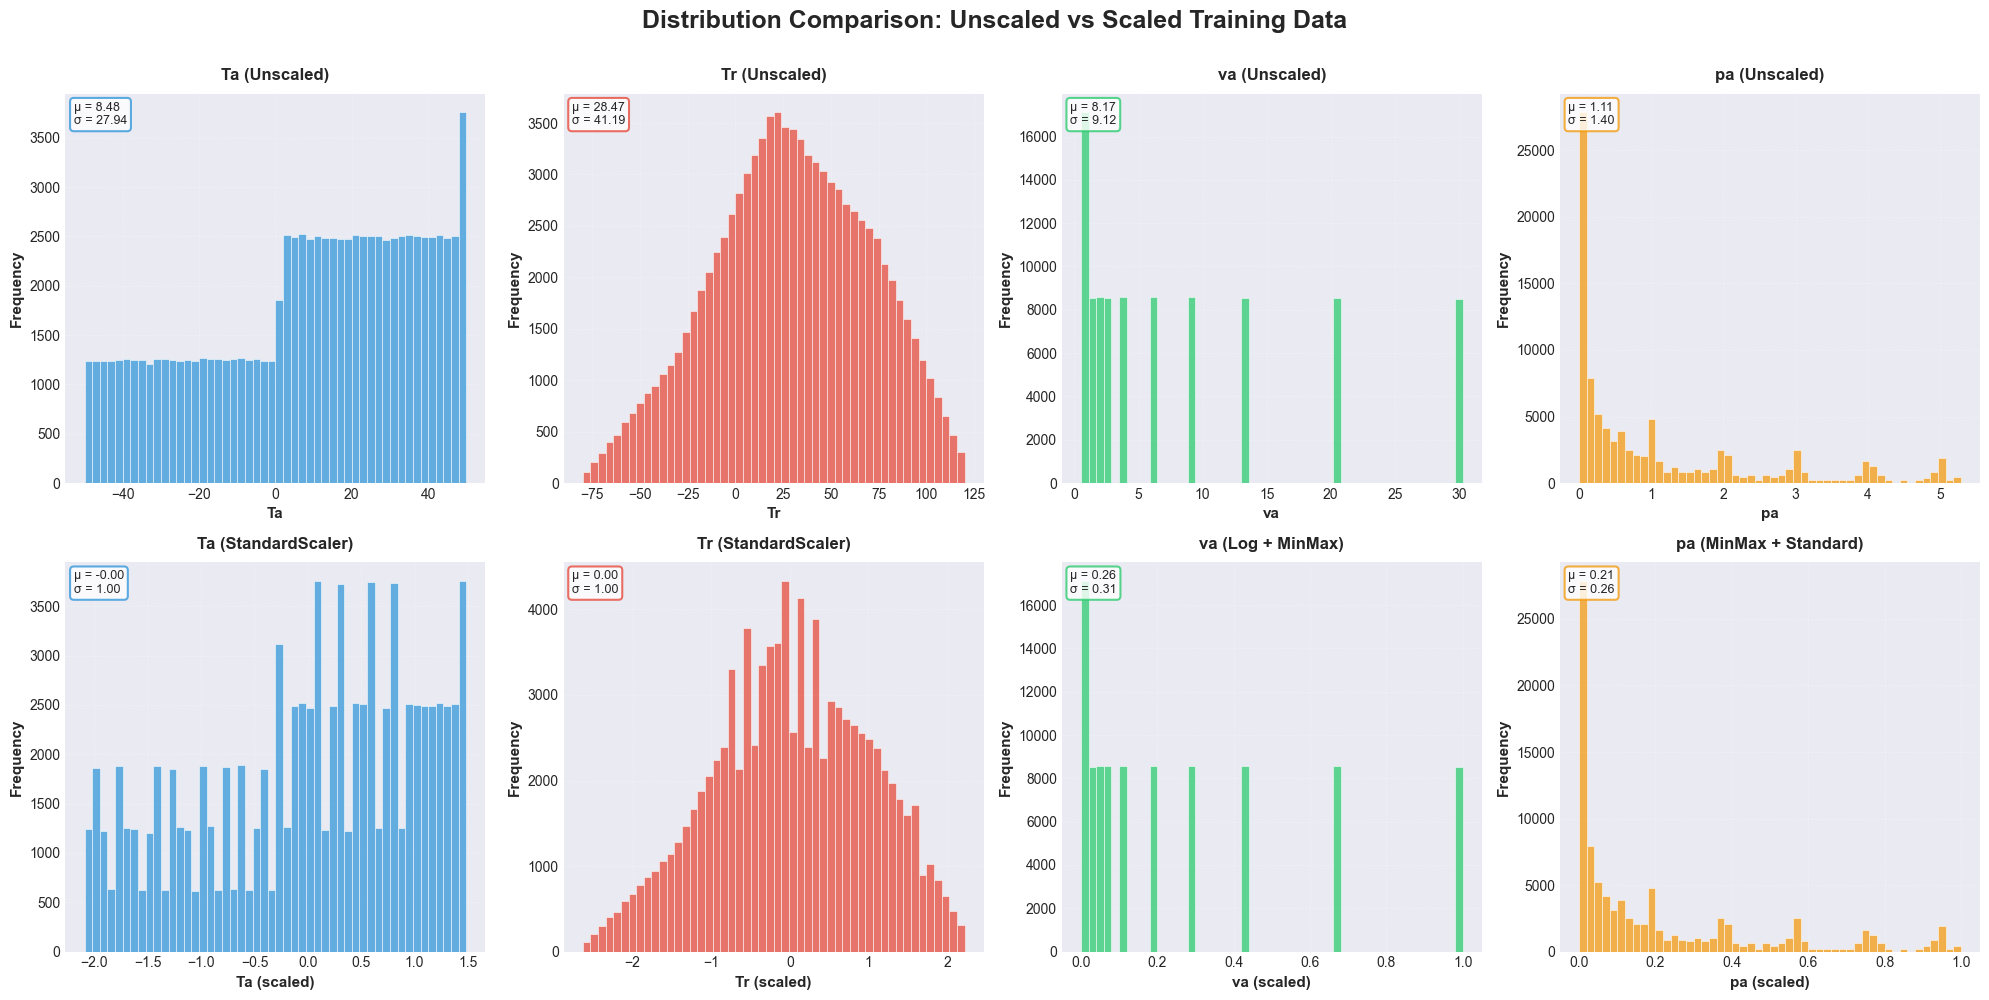

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming X_train and X_train_scaled are already defined
# Convert to DataFrames
X_train_df = pd.DataFrame(
    X_train, 
    columns=['Ta', 'Tr', 'va', 'pa']
)

X_train_scaled_df = pd.DataFrame(
    X_train_scaled, 
    columns=['Ta', 'Tr', 'va', 'pa']
)

# Set style for better aesthetics
plt.style.use('seaborn-v0_8-darkgrid')
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']  # Professional color palette

# Create subplots: 2 rows x 4 columns
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Distribution Comparison: Unscaled vs Scaled Training Data', 
             fontsize=18, fontweight='bold', y=0.995)

variables = ['Ta', 'Tr', 'va', 'pa']
scaling_methods = ['StandardScaler', 'StandardScaler', 'Log + MinMax', 'MinMax + Standard']

# Plot each variable
for i, (var, method, color) in enumerate(zip(variables, scaling_methods, colors)):
    # Top row: Unscaled data
    axes[0, i].hist(X_train_df[var], bins=50, alpha=0.75, 
                    color=color, edgecolor='white', linewidth=0.5)
    axes[0, i].set_xlabel(f'{var}', fontsize=11, fontweight='bold')
    axes[0, i].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[0, i].set_title(f'{var} (Unscaled)', fontsize=12, fontweight='bold', pad=10)
    axes[0, i].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    axes[0, i].spines['top'].set_visible(False)
    axes[0, i].spines['right'].set_visible(False)
    
    # Add statistics text
    mean_val = X_train_df[var].mean()
    std_val = X_train_df[var].std()
    axes[0, i].text(0.02, 0.98, f'μ = {mean_val:.2f}\nσ = {std_val:.2f}',
                    transform=axes[0, i].transAxes, fontsize=9,
                    verticalalignment='top', bbox=dict(boxstyle='round', 
                    facecolor='white', alpha=0.8, edgecolor=color, linewidth=1.5))
    
    # Bottom row: Scaled data
    axes[1, i].hist(X_train_scaled_df[var], bins=50, alpha=0.75, 
                    color=color, edgecolor='white', linewidth=0.5)
    axes[1, i].set_xlabel(f'{var} (scaled)', fontsize=11, fontweight='bold')
    axes[1, i].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[1, i].set_title(f'{var} ({method})', fontsize=12, fontweight='bold', pad=10)
    axes[1, i].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    axes[1, i].spines['top'].set_visible(False)
    axes[1, i].spines['right'].set_visible(False)
    
    # Add statistics text
    mean_val_scaled = X_train_scaled_df[var].mean()
    std_val_scaled = X_train_scaled_df[var].std()
    axes[1, i].text(0.02, 0.98, f'μ = {mean_val_scaled:.2f}\nσ = {std_val_scaled:.2f}',
                    transform=axes[1, i].transAxes, fontsize=9,
                    verticalalignment='top', bbox=dict(boxstyle='round', 
                    facecolor='white', alpha=0.8, edgecolor=color, linewidth=1.5))

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

### Convert data to tensors for pytorch

In [7]:
# Convert scaled data to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

### Hyperparameter Selection

In [ ]:
# Define NN model. The archetecture is chosen as the best performing model based off of four archetectures tested. 
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        self.model = nn.Sequential( 
            nn.Linear(4, 80),
            nn.ReLU(),
            nn.Linear(80, 70),
            nn.ReLU(),
            nn.Linear(70, 55),
            nn.ReLU(),
            nn.Linear(55, 1)
        )

    def forward(self, x):
        return self.model(x)

model = NeuralNet()


# Initialize the criterion and the optimiser functions
criterion = nn.L1Loss()
weight_decay = 1e-2 # L2 regularization
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)

In [9]:
epochs = 50
train_losses = []
val_losses = []

In [11]:
# Batch the data and shuffle it
dataset = TensorDataset(X_train_tensor, y_train_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [12]:
# Training loop 
for epoch in range(epochs):
    model.train()

    epoch_train_loss = 0.0
    num_batches = 0

    for batch_X, batch_y in dataloader:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        num_batches += 1
    
    avg_train_loss = epoch_train_loss / num_batches

    # Keep track of losses
    model.eval()

    with torch.no_grad():
        val_output = model(X_val_tensor)
        val_loss = criterion(val_output, y_val_tensor)
    
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss.item())

    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss.item():.4f}")

Epoch 1, Train Loss: 2.1135, Val Loss: 0.9469
Epoch 2, Train Loss: 0.9027, Val Loss: 0.8153
Epoch 3, Train Loss: 0.8163, Val Loss: 0.7903
Epoch 4, Train Loss: 0.7756, Val Loss: 0.6981
Epoch 5, Train Loss: 0.7229, Val Loss: 0.6288
Epoch 6, Train Loss: 0.6749, Val Loss: 0.6233
Epoch 7, Train Loss: 0.6381, Val Loss: 0.7268
Epoch 8, Train Loss: 0.6063, Val Loss: 0.6408
Epoch 9, Train Loss: 0.5907, Val Loss: 0.6086
Epoch 10, Train Loss: 0.5613, Val Loss: 0.5373
Epoch 11, Train Loss: 0.5565, Val Loss: 0.5090
Epoch 12, Train Loss: 0.5388, Val Loss: 0.4968
Epoch 13, Train Loss: 0.5195, Val Loss: 0.4905
Epoch 14, Train Loss: 0.5162, Val Loss: 0.5316
Epoch 15, Train Loss: 0.5123, Val Loss: 0.5202
Epoch 16, Train Loss: 0.4980, Val Loss: 0.4543
Epoch 17, Train Loss: 0.5021, Val Loss: 0.4281
Epoch 18, Train Loss: 0.4796, Val Loss: 0.4521
Epoch 19, Train Loss: 0.4810, Val Loss: 0.4390
Epoch 20, Train Loss: 0.4763, Val Loss: 0.5134
Epoch 21, Train Loss: 0.4726, Val Loss: 0.5152
Epoch 22, Train Loss: 

In [15]:
def plot_loss_per_epoch(train_losses, val_losses, epochs):
    # ---- Plot all losses on one figure ----
    plt.figure(figsize=(8, 5))

    # Plot all lines on the same axes
    plt.plot(range(1, epochs + 1), np.log(train_losses), label='Training Loss', color='black')
    plt.plot(range(1, epochs + 1), np.log(val_losses), label='Validation Loss', color='red')

    # Labels and title
    plt.title("Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("log MSE Loss")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    return plt

def evaluate_with_tolerance_bands(y_true, y_pred, dataset_name="Test"):
    """
    Comprehensive evaluation including tolerance bands for UTCI predictions.
    
    Parameters:
    -----------
    y_true : array-like
        True UTCI offset values
    y_pred : array-like
        Predicted UTCI offset values
    dataset_name : str
        Name of the dataset being evaluated
    
    Returns:
    --------
    dict : Dictionary containing all metrics
    """
    
    # Convert to numpy arrays if needed
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    # Calculate absolute errors
    abs_errors = np.abs(y_pred - y_true)
    
    # Standard metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mbe = np.mean(y_pred - y_true)  # Mean Bias Error
    r2 = r2_score(y_true, y_pred)
    
    # Tolerance bands
    within_0_5 = np.mean(abs_errors <= 0.5) * 100
    within_1_0 = np.mean(abs_errors <= 1.0) * 100
    within_2_0 = np.mean(abs_errors <= 2.0) * 100
    
    # Additional useful metrics
    max_error = np.max(abs_errors)
    percentile_90 = np.percentile(abs_errors, 90)
    percentile_95 = np.percentile(abs_errors, 95)
    
    # Print results
    print(f"\n{'='*60}")
    print(f"{dataset_name.upper()} SET EVALUATION")
    print(f"{'='*60}")
    print(f"\nStandard Metrics:")
    print(f"  MAE (Mean Absolute Error):     {mae:.4f}°C")
    print(f"  RMSE (Root Mean Squared Error): {rmse:.4f}°C")
    print(f"  MBE (Mean Bias Error):         {mbe:+.4f}°C")
    print(f"  R² (Coefficient of Determination): {r2:.4f}")
    
    print(f"\nTolerance Bands (% of predictions within):")
    print(f"  ±0.5°C: {within_0_5:5.1f}%  {'✓ Excellent' if within_0_5 >= 80 else ''}")
    print(f"  ±1.0°C: {within_1_0:5.1f}%  {'✓ Good' if within_1_0 >= 90 else ''}")
    print(f"  ±2.0°C: {within_2_0:5.1f}%  {'✓ Acceptable' if within_2_0 >= 95 else ''}")
    
    print(f"\nError Distribution:")
    print(f"  Maximum absolute error: {max_error:.4f}°C")
    print(f"  90th percentile error:  {percentile_90:.4f}°C")
    print(f"  95th percentile error:  {percentile_95:.4f}°C")
    print(f"  Number of samples:      {len(y_true)}")
    print(f"{'='*60}\n")
    
    # Return dictionary for further analysis
    return {
        'mae': mae,
        'rmse': rmse,
        'mbe': mbe,
        'r2': r2,
        'within_0_5': within_0_5,
        'within_1_0': within_1_0,
        'within_2_0': within_2_0,
        'max_error': max_error,
        'p90_error': percentile_90,
        'p95_error': percentile_95,
        'n_samples': len(y_true)
    }

def plot_tolerance_analysis(y_true, y_pred, dataset_name="Test"):
    """
    Create visualization of tolerance band performance.
    
    Parameters:
    -----------
    y_true : array-like
        True UTCI offset values
    y_pred : array-like
        Predicted UTCI offset values
    dataset_name : str
        Name of the dataset being evaluated
    """
    
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    abs_errors = np.abs(y_pred - y_true)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'UTCI Emulator Performance Analysis - {dataset_name} Set', 
                 fontsize=14, fontweight='bold')
    
    # 1. Prediction vs True scatter plot with tolerance bands
    ax1 = axes[0, 0]
    ax1.scatter(y_true, y_pred, alpha=0.5, s=20, edgecolors='k', linewidths=0.5)
    
    # Perfect prediction line
    min_val, max_val = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
    
    # Tolerance bands
    ax1.fill_between([min_val, max_val], 
                     [min_val - 0.5, max_val - 0.5], 
                     [min_val + 0.5, max_val + 0.5], 
                     alpha=0.2, color='green', label='±0.5°C band')
    ax1.fill_between([min_val, max_val], 
                     [min_val - 1.0, max_val - 1.0], 
                     [min_val + 1.0, max_val + 1.0], 
                     alpha=0.1, color='yellow', label='±1.0°C band')
    
    ax1.set_xlabel('True UTCI Offset (°C)', fontsize=11)
    ax1.set_ylabel('Predicted UTCI Offset (°C)', fontsize=11)
    ax1.set_title('Predictions vs True Values')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal', adjustable='box')
    
    # 2. Error distribution histogram
    ax2 = axes[0, 1]
    ax2.hist(abs_errors, bins=50, edgecolor='black', alpha=0.7)
    ax2.axvline(0.5, color='green', linestyle='--', linewidth=2, label='±0.5°C')
    ax2.axvline(1.0, color='orange', linestyle='--', linewidth=2, label='±1.0°C')
    ax2.axvline(2.0, color='red', linestyle='--', linewidth=2, label='±2.0°C')
    ax2.set_xlabel('Absolute Error (°C)', fontsize=11)
    ax2.set_ylabel('Frequency', fontsize=11)
    ax2.set_title('Error Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Cumulative error distribution
    ax3 = axes[1, 0]
    sorted_errors = np.sort(abs_errors)
    cumulative = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100
    ax3.plot(sorted_errors, cumulative, linewidth=2)
    ax3.axvline(0.5, color='green', linestyle='--', linewidth=2, alpha=0.7)
    ax3.axvline(1.0, color='orange', linestyle='--', linewidth=2, alpha=0.7)
    ax3.axvline(2.0, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax3.axhline(95, color='gray', linestyle=':', linewidth=1)
    ax3.set_xlabel('Absolute Error (°C)', fontsize=11)
    ax3.set_ylabel('Cumulative Percentage (%)', fontsize=11)
    ax3.set_title('Cumulative Error Distribution')
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(left=0)
    
    # Add annotations
    within_0_5 = np.mean(abs_errors <= 0.5) * 100
    within_1_0 = np.mean(abs_errors <= 1.0) * 100
    within_2_0 = np.mean(abs_errors <= 2.0) * 100
    ax3.text(0.5, within_0_5, f'{within_0_5:.1f}%', 
             verticalalignment='bottom', fontsize=9, color='green', fontweight='bold')
    ax3.text(1.0, within_1_0, f'{within_1_0:.1f}%', 
             verticalalignment='bottom', fontsize=9, color='orange', fontweight='bold')
    ax3.text(2.0, within_2_0, f'{within_2_0:.1f}%', 
             verticalalignment='bottom', fontsize=9, color='red', fontweight='bold')
    
    # 4. Residuals vs Predicted (check for bias)
    ax4 = axes[1, 1]
    residuals = y_pred - y_true
    ax4.scatter(y_true, residuals, alpha=0.5, s=20, edgecolors='k', linewidths=0.5)
    ax4.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
    ax4.axhline(0.5, color='green', linestyle=':', linewidth=1, alpha=0.5)
    ax4.axhline(-0.5, color='green', linestyle=':', linewidth=1, alpha=0.5)
    ax4.axhline(1.0, color='orange', linestyle=':', linewidth=1, alpha=0.5)
    ax4.axhline(-1.0, color='orange', linestyle=':', linewidth=1, alpha=0.5)
    ax4.set_xlabel('True UTCI Offset (°C)', fontsize=11)
    ax4.set_ylabel('Residual (°C)', fontsize=11)
    ax4.set_title('Residual Plot')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig



In [16]:
def model_evaluation_and_plots(save_path="../results/hyperparameter_tuning", model_name="utci_nn_model", model=model, train_losses= train_losses, val_losses= val_losses, epochs =50):
    model_dir = os.path.join(save_path, model_name)

    # Evaluate the model
    model.eval()
    with torch.no_grad():
        y_pred_train = model(X_train_tensor).numpy()
        y_pred_val = model(X_val_tensor).numpy()


    train_metrics = evaluate_with_tolerance_bands(y_train.values, y_pred_train, "Training")
    val_metrics = evaluate_with_tolerance_bands(y_val.values, y_pred_val, "Validation")

    metrics_df = pd.DataFrame([
        {"dataset": "Training", **train_metrics},
        {"dataset": "Validation", **val_metrics}
    ])

    # Create visualizations
    train_losses = plot_loss_per_epoch(train_losses, val_losses, epochs)
    fig_train = plot_tolerance_analysis(y_train.values, y_pred_train, "Training")
    fig_val = plot_tolerance_analysis(y_val.values, y_pred_val, "Validation")

    # save results
    train_losses.savefig(os.path.join(save_path, f"{model_name}_training_losses.png"))
    fig_train.savefig(os.path.join(save_path, f"{model_name}_tolerance_training.png"))
    fig_val.savefig(os.path.join(save_path, f"{model_name}_tolerance_validation.png"))


    # Save metrics to CSV

    metrics_df.to_csv(    os.path.join(save_path, f"{model_name}_metrics.csv"), index=False)


    print(f"Model evaluation and plots saved in {model_dir}")


TRAINING SET EVALUATION

Standard Metrics:
  MAE (Mean Absolute Error):     0.3971°C
  RMSE (Root Mean Squared Error): 0.5517°C
  MBE (Mean Bias Error):         +0.1238°C
  R² (Coefficient of Determination): 0.9991

Tolerance Bands (% of predictions within):
  ±0.5°C:  72.9%  
  ±1.0°C:  93.6%  ✓ Good
  ±2.0°C:  99.2%  ✓ Acceptable

Error Distribution:
  Maximum absolute error: 5.4367°C
  90th percentile error:  0.8281°C
  95th percentile error:  1.0995°C
  Number of samples:      94178


VALIDATION SET EVALUATION

Standard Metrics:
  MAE (Mean Absolute Error):     0.3991°C
  RMSE (Root Mean Squared Error): 0.5572°C
  MBE (Mean Bias Error):         +0.1155°C
  R² (Coefficient of Determination): 0.9991

Tolerance Bands (% of predictions within):
  ±0.5°C:  73.1%  
  ±1.0°C:  93.7%  ✓ Good
  ±2.0°C:  99.0%  ✓ Acceptable

Error Distribution:
  Maximum absolute error: 3.8289°C
  90th percentile error:  0.8402°C
  95th percentile error:  1.0919°C
  Number of samples:      10465

Model eval

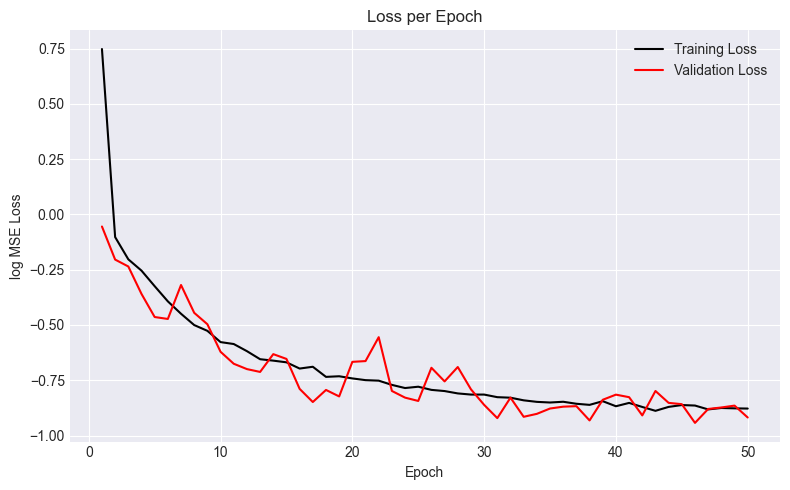

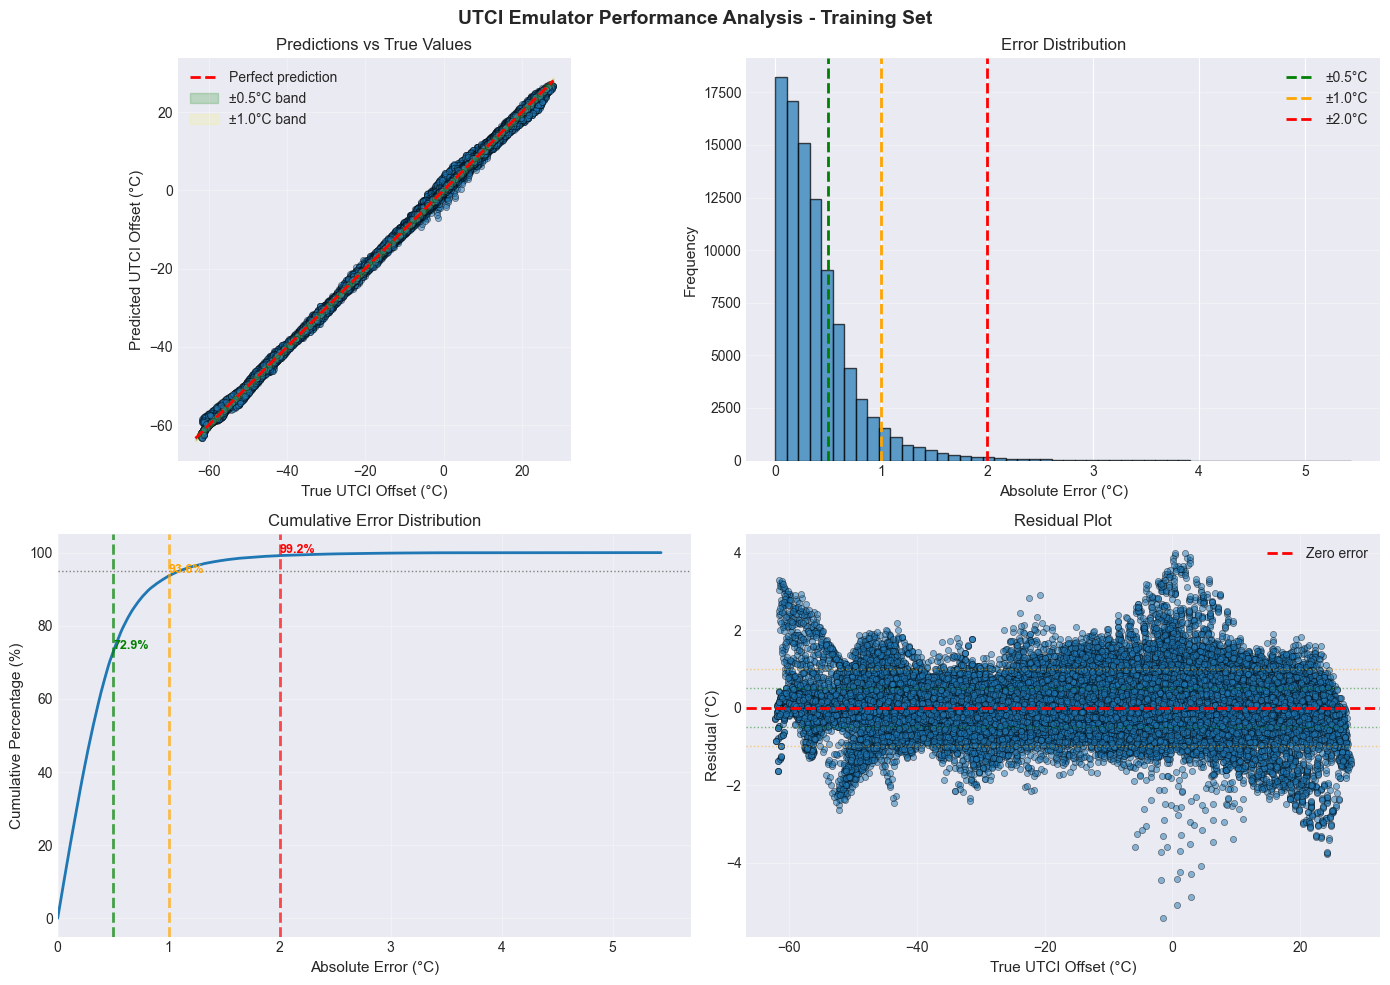

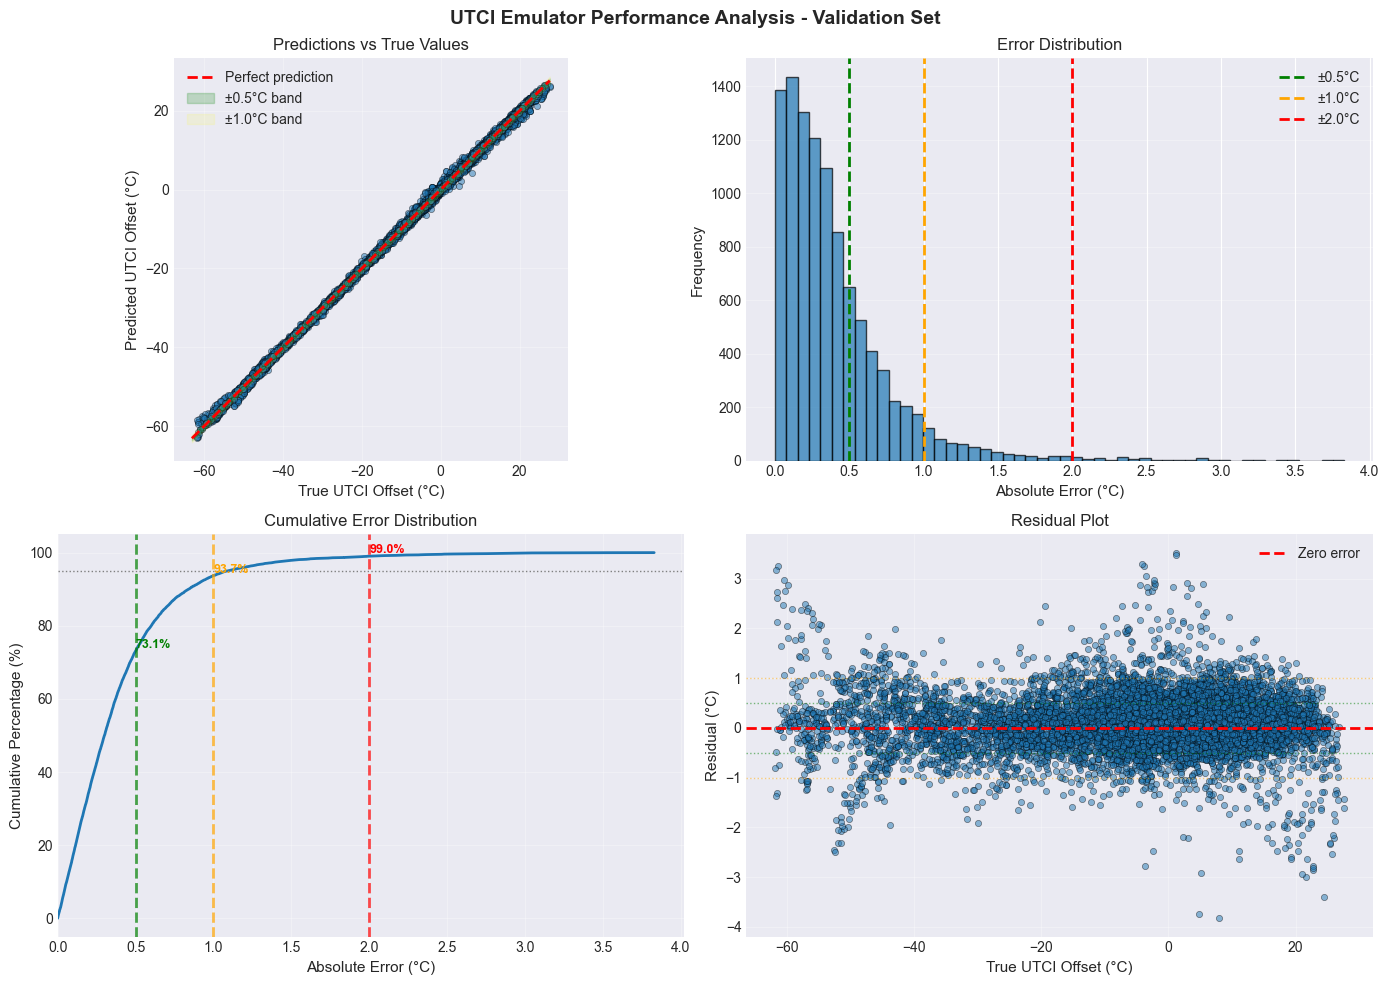

In [17]:
model_evaluation_and_plots(save_path="../results/hyperparameter_tuning", model_name="shape_100_100_100_L1_loss_50_epochs", model=model, epochs =50)


TEST SET EVALUATION

Standard Metrics:
  MAE (Mean Absolute Error):     0.3985°C
  RMSE (Root Mean Squared Error): 0.5409°C
  MBE (Mean Bias Error):         +0.1179°C
  R² (Coefficient of Determination): 0.9989

Tolerance Bands (% of predictions within):
  ±0.5°C:  72.0%  
  ±1.0°C:  93.8%  ✓ Good
  ±2.0°C:  99.2%  ✓ Acceptable

Error Distribution:
  Maximum absolute error: 2.9756°C
  90th percentile error:  0.8155°C
  95th percentile error:  1.0564°C
  Number of samples:      1000



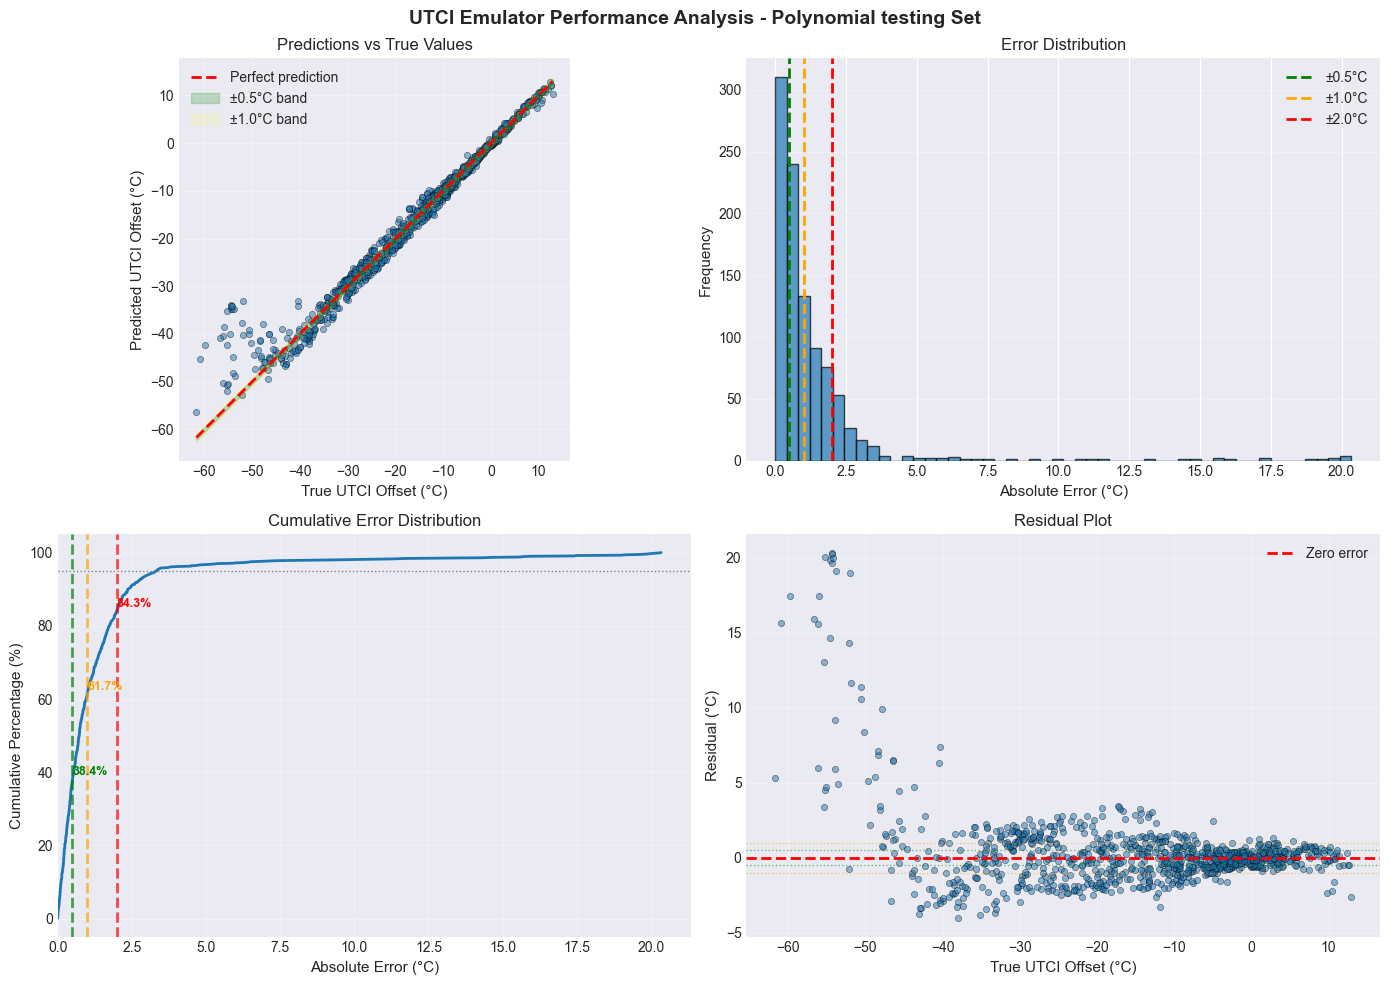

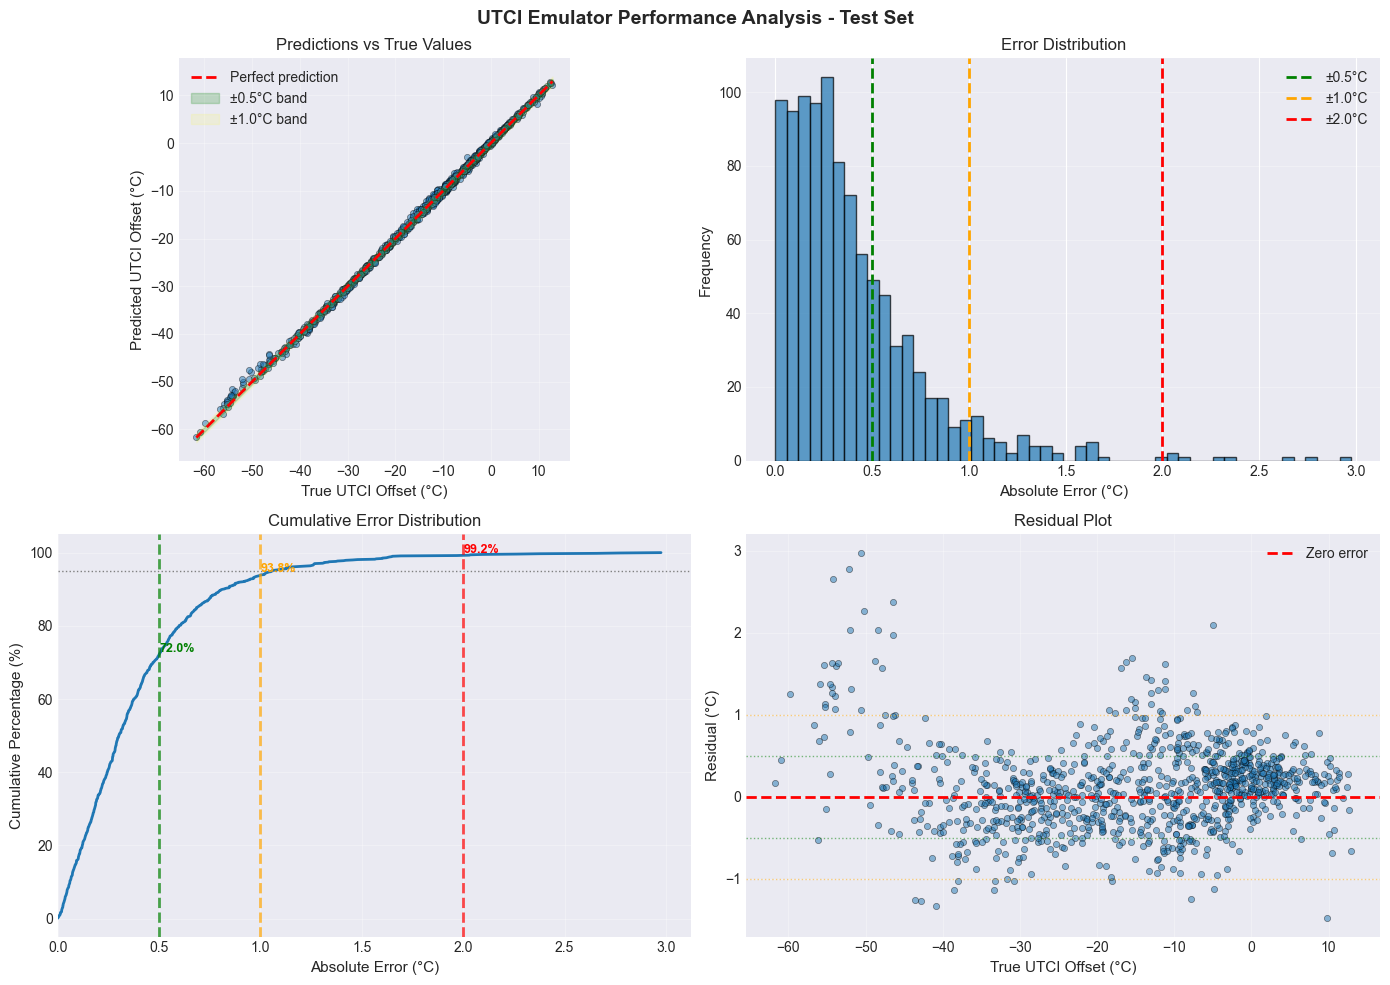

In [19]:
# Comprehensive evaluation with tolerance bands
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_tensor).numpy()

# Evaluate all datasets
test_metrics = evaluate_with_tolerance_bands(y_test.values, y_pred_test, "Test")

# Create visualizations
fig_poly = plot_tolerance_analysis(test['Offset'], test['UTCI_polynomial'] - test['Ta'], "Polynomial testing")
fig_test = plot_tolerance_analysis(test['Offset'], y_pred_test, "Test")
plt.show()